# XGBoost (eXtreme Gradient Boosting)

Imports

In [ ]:
# Imports
from xgboost import XGBClassifier
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/train.csv")

# Feature / Target split
drop_cols = ['ID', 'result', 'age_desc']
X = df.drop(['Class/ASD'] + drop_cols, axis=1)
y = df['Class/ASD']

# Encode categorical features
X_encoded = pd.get_dummies(X, drop_first=True)

# Scale features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_encoded)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# XGBoost WITH SelectKBest

In [ ]:
# Feature Selection
selector = SelectKBest(score_func=chi2, k=10)
X_train_kbest = selector.fit_transform(X_train, y_train)
X_test_kbest = selector.transform(X_test)

# XGBoost model
xgb_kbest = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

xgb_kbest.fit(X_train_kbest, y_train)

# Prediction
y_pred_kbest = xgb_kbest.predict(X_test_kbest)

print("XGBoost + SelectKBest Accuracy:",
      accuracy_score(y_test, y_pred_kbest))

XGBoost + SelectKBest Accuracy: 0.8375


# XGBoost WITHOUT SelectKBest

In [ ]:
# XGBoost without feature selection
xgb_full = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

xgb_full.fit(X_train, y_train)

# Prediction
y_pred_full = xgb_full.predict(X_test)

print("XGBoost without SelectKBest Accuracy:",
      accuracy_score(y_test, y_pred_full))

XGBoost without SelectKBest Accuracy: 0.85625


# Side-by-Side Comparison

In [ ]:
print("\n--- Classification Report (With SelectKBest) ---")
print(classification_report(y_test, y_pred_kbest))

print("\n--- Classification Report (Without SelectKBest) ---")
print(classification_report(y_test, y_pred_full))


--- Classification Report (With SelectKBest) ---
              precision    recall  f1-score   support

           0       0.90      0.90      0.90       128
           1       0.59      0.59      0.59        32

    accuracy                           0.84       160
   macro avg       0.75      0.75      0.75       160
weighted avg       0.84      0.84      0.84       160


--- Classification Report (Without SelectKBest) ---
              precision    recall  f1-score   support

           0       0.91      0.91      0.91       128
           1       0.64      0.66      0.65        32

    accuracy                           0.86       160
   macro avg       0.77      0.78      0.78       160
weighted avg       0.86      0.86      0.86       160



# Accuracy Comparison (Bar Chart)

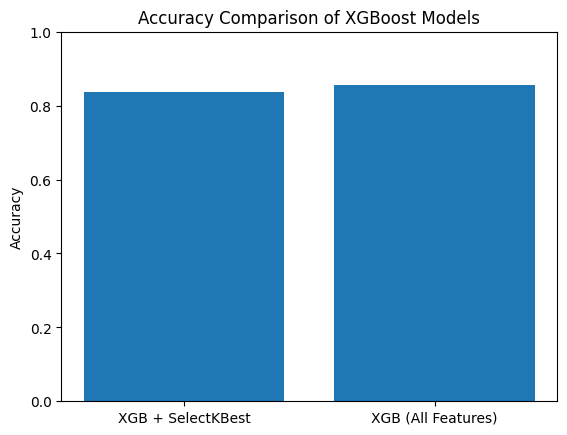

In [ ]:
import matplotlib.pyplot as plt

models = ['XGB + SelectKBest', 'XGB (All Features)']
accuracies = [
    accuracy_score(y_test, y_pred_kbest),
    accuracy_score(y_test, y_pred_full)
]

plt.figure()
plt.bar(models, accuracies)
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of XGBoost Models")
plt.ylim(0, 1)
plt.show()

# Confusion Matrix – Side by Side

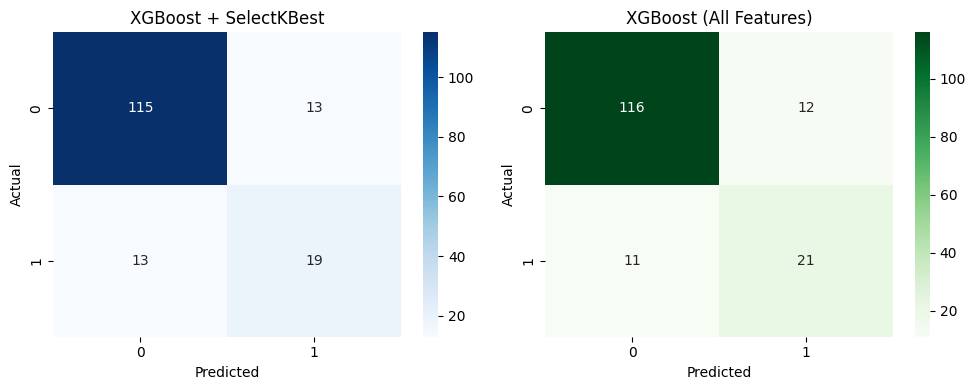

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.heatmap(confusion_matrix(y_test, y_pred_kbest),
            annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("XGBoost + SelectKBest")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(confusion_matrix(y_test, y_pred_full),
            annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title("XGBoost (All Features)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

# Precision / Recall / F1 Comparison

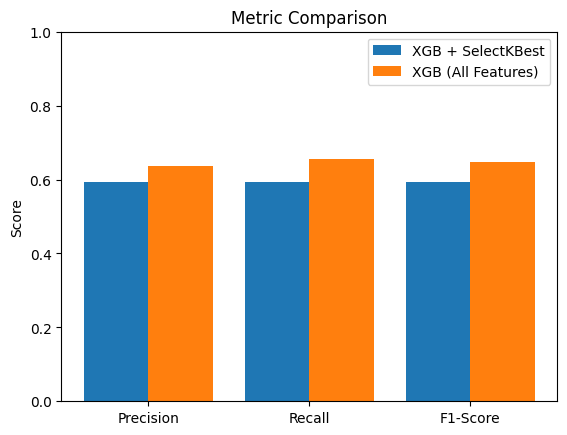

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

metrics = ['Precision', 'Recall', 'F1-Score']

kbest_scores = [
    precision_score(y_test, y_pred_kbest),
    recall_score(y_test, y_pred_kbest),
    f1_score(y_test, y_pred_kbest)
]

full_scores = [
    precision_score(y_test, y_pred_full),
    recall_score(y_test, y_pred_full),
    f1_score(y_test, y_pred_full)
]

x = range(len(metrics))

plt.figure()
plt.bar(x, kbest_scores, width=0.4, label='XGB + SelectKBest')
plt.bar([i + 0.4 for i in x], full_scores, width=0.4, label='XGB (All Features)')

plt.xticks([i + 0.2 for i in x], metrics)
plt.ylabel("Score")
plt.title("Metric Comparison")
plt.legend()
plt.ylim(0, 1)
plt.show()

# Feature Importance (XGBoost – All Features)

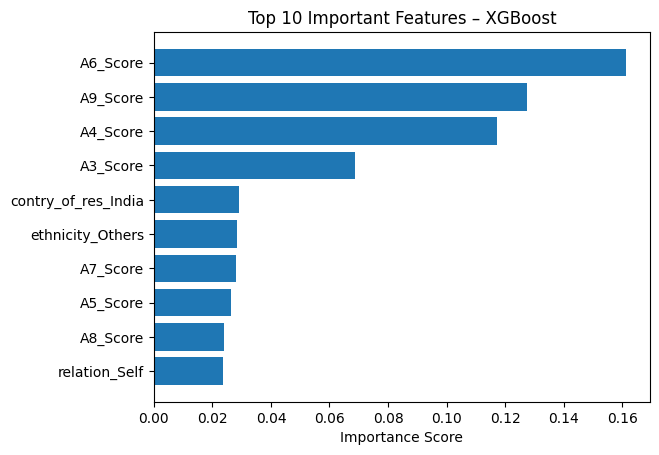

In [ ]:
importances = xgb_full.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(10)

plt.figure()
plt.barh(feat_imp['Feature'], feat_imp['Importance'])
plt.title("Top 10 Important Features – XGBoost")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
acc_kbest = accuracy_score(y_test, y_pred_kbest)
acc_full = accuracy_score(y_test, y_pred_full)

print(f"Final Accuracy (XGBoost + SelectKBest): {acc_kbest*100:.2f}%")
print(f"Final Accuracy (XGBoost - All Features): {acc_full*100:.2f}%")

Final Accuracy (XGBoost + SelectKBest): 83.75%
Final Accuracy (XGBoost - All Features): 85.62%


In [ ]:
if acc_kbest > acc_full:
    print("Best Model: XGBoost + SelectKBest")
    print(f"Final Accuracy: {acc_kbest*100:.2f}%")
else:
    print("Best Model: XGBoost (All Features)")
    print(f"Final Accuracy: {acc_full*100:.2f}%")

Best Model: XGBoost (All Features)
Final Accuracy: 85.62%
